<a href="https://colab.research.google.com/github/redgrave17/finalproject/blob/claude%2Faffectionate-allen-8eoaxi/gb_demand_forecast_aligned_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting Great Britain's daily peak electricity demand

In [1]:
# Colab has statsmodels & pandas preinstalled. No pmdarima (NumPy-2.x incompatible).
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_breuschpagan
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## 1. Read, prepare, and split the data

In [2]:
try:
    import kagglehub
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
    import kagglehub
import glob

path = kagglehub.dataset_download("albertovidalrod/electricity-consumption-uk-20092022")
print("Path to dataset files:", path)

# Pick the half-hourly demand file from the download (prefer the 2009-2024 file).
csvs = sorted(glob.glob(os.path.join(path, "**", "*.csv"), recursive=True))
CSV = next((c for c in csvs if "2024" in os.path.basename(c)),
           next((c for c in csvs if "historic_demand" in os.path.basename(c).lower()), csvs[0]))
print("Using file:", os.path.basename(CSV))

raw = pd.read_csv(CSV)

# Parse the date column (ISO, or with a time component; fall back to day-first).
d = pd.to_datetime(raw["settlement_date"], errors="coerce")
miss = d.isna()
if miss.any():
    d.loc[miss] = pd.to_datetime(raw.loc[miss, "settlement_date"], dayfirst=True, errors="coerce")
raw["date"] = d.dt.normalize()

# Collapse the half-hours to one row per day.
g = raw.groupby("date")
day = pd.DataFrame({
    "peak_gw":      g["nd"].max() / 1000,                       # daily maximum National Demand, GW
    "solar_cap_gw": g["embedded_solar_capacity"].max() / 1000,  # GW
    "is_holiday":   g["is_holiday"].max().astype(bool),         # dataset's own flag
}).reset_index().sort_values("date").reset_index(drop=True)

t0 = day["date"].min()
day["t_days"] = (day["date"] - t0).dt.days.astype(float)
day["trend"]  = day["t_days"] / 365.2425                        # years since first day
WDAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]       # Monday = reference level
day["wday"] = pd.Categorical([WDAYS[x] for x in day["date"].dt.weekday], categories=WDAYS)
day["hol"]  = day["is_holiday"].astype(int)

# Annual Fourier pairs on continuous elapsed time, s1..s6 / c1..c6.
for k in range(1, 7):
    day[f"s{k}"] = np.sin(2 * np.pi * k * day["t_days"] / 365.2425)
    day[f"c{k}"] = np.cos(2 * np.pi * k * day["t_days"] / 365.2425)

# Train / holdout split fixed at 31 Dec 2023.
train = day[day["date"] <= "2023-12-31"].copy()
test  = day[day["date"] >= "2024-01-01"].copy()
print(f"day: {len(day)} rows  |  train: {len(train)}  test: {len(test)}")


100%|██████████| 20.6M/20.6M [00:00<00:00, 79.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/albertovidalrod/electricity-consumption-uk-20092022/versions/85
Using file: historic_demand_2009_2024.csv
day: 5818 rows  |  train: 5478  test: 340


## 2. Fourier order chosen on the training data only (elbow rule)
Pick the largest $K$ before the next harmonic adds less than 0.002 to adjusted $R^2$. AICc is reported
for context but is **not** used to choose $K$ (with ~5,500 training days it keeps falling past
practically negligible gains). AICc uses R's `lm` definition so the values match the report.

In [3]:
def _ols_fourier(K, data):
    cols = ["trend"] + [f"{p}{k}" for k in range(1, K + 1) for p in ("s", "c")] + ["solar_cap_gw"]
    X = pd.get_dummies(data["wday"], drop_first=True).astype(float)      # Tue..Sun (Mon reference)
    Xd = pd.concat([data[cols].reset_index(drop=True), X.reset_index(drop=True)], axis=1)
    Xd = sm.add_constant(Xd)
    Xd["is_holiday"] = data["is_holiday"].astype(float).values
    return sm.OLS(data["peak_gw"].values, Xd.astype(float)).fit()

def _aicc_lm(rss, n, ncoef):
    ll = -0.5 * n * (np.log(2 * np.pi) + 1 + np.log(rss / n))            # R lm log-likelihood
    k = ncoef + 1                                                        # + sigma
    return (-2 * ll + 2 * k) + 2 * k * (k + 1) / (n - k - 1)

rows = []
for K in range(1, 7):
    r = _ols_fourier(K, train)
    rows.append({"K": K, "adj_R2": r.rsquared_adj, "AICc": _aicc_lm(r.ssr, int(r.nobs), len(r.params))})
k_tab = pd.DataFrame(rows)
k_tab["delta"] = k_tab["adj_R2"].diff()
first_small = k_tab.index[k_tab["delta"] < 0.002]
K_final = int(k_tab.loc[first_small[0], "K"] - 1) if len(first_small) else 6
print(k_tab[["K", "adj_R2", "delta", "AICc"]].round(5).to_string(index=False))
print("K_final =", K_final)

 K  adj_R2   delta        AICc
 1 0.91565     NaN 23777.42800
 2 0.91840 0.00275 23597.60061
 3 0.92818 0.00978 22900.47759
 4 0.92989 0.00171 22770.36556
 5 0.93071 0.00081 22708.35510
 6 0.93256 0.00185 22561.99791
K_final = 3


## 3. Descriptive full-sample model + robust inference
Full-sample fit used **only to report effect sizes** (not to choose K or to forecast). Standard errors
are Newey–West (HAC, Bartlett kernel, bandwidth 14, no small-sample correction) to match the R
`sandwich::NeweyWest(lag = 14, prewhite = FALSE)` call. Day-of-week is tested as one omnibus family.

In [4]:
desc = smf.ols(
    "peak_gw ~ trend + s1+c1+s2+c2+s3+c3 + C(wday) + is_holiday + solar_cap_gw",
    data=day
).fit(cov_type="HAC", cov_kwds={"maxlags": 14, "use_correction": False})

lab = {"trend": "Trend, per year",
       "s1": "sin(1x annual)", "c1": "cos(1x annual)", "s2": "sin(2x annual)",
       "c2": "cos(2x annual)", "s3": "sin(3x annual)", "c3": "cos(3x annual)",
       "C(wday)[T.Tue]": "Tuesday vs Monday",  "C(wday)[T.Wed]": "Wednesday vs Monday",
       "C(wday)[T.Thu]": "Thursday vs Monday", "C(wday)[T.Fri]": "Friday vs Monday",
       "C(wday)[T.Sat]": "Saturday vs Monday", "C(wday)[T.Sun]": "Sunday vs Monday",
       "is_holiday[T.True]": "Public holiday", "solar_cap_gw": "Embedded solar capacity, per GW"}
eff = []
for term, name in lab.items():
    b, se, p = desc.params[term], desc.bse[term], desc.pvalues[term]
    eff.append({"Effect": name, "Effect (GW)": round(b, 2),
                "95% CI (GW)": f"{b-1.96*se:.2f} to {b+1.96*se:.2f}",
                "p": "<0.001" if p < 0.001 else f"{p:.3f}"})
effects = pd.DataFrame(eff)
print("Adjusted R^2 =", round(desc.rsquared_adj, 4))
print(effects.to_string(index=False))

# Omnibus F-test for the whole day-of-week family (classical nested comparison).
red = smf.ols("peak_gw ~ trend + s1+c1+s2+c2+s3+c3 + is_holiday + solar_cap_gw", data=day).fit()
df_diff = int(desc.df_model - red.df_model)
F = ((red.ssr - desc.ssr) / df_diff) / (desc.ssr / desc.df_resid)
print(f"Day-of-week omnibus F({df_diff}, {int(desc.df_resid)}) = {F:.0f}")

# Descriptive sensitivity only (quadratic trend); labelled, not the forecasting model.
quad = smf.ols("peak_gw ~ trend + I(trend**2) + s1+c1+s2+c2+s3+c3 + C(wday) + is_holiday + solar_cap_gw",
               data=day).fit()
print(f"Quadratic-trend sensitivity: AIC linear={desc.aic:.0f}  quadratic={quad.aic:.0f}  "
      f"quad coef={quad.params['I(trend ** 2)']:.4f}")

Adjusted R^2 = 0.9294
                         Effect  Effect (GW)    95% CI (GW)      p
                Trend, per year        -0.76 -0.87 to -0.65 <0.001
                 sin(1x annual)         0.43   0.24 to 0.62 <0.001
                 cos(1x annual)         7.49   7.29 to 7.69 <0.001
                 sin(2x annual)         0.11  -0.06 to 0.29  0.208
                 cos(2x annual)         0.52   0.30 to 0.73 <0.001
                 sin(3x annual)         0.07  -0.11 to 0.26  0.442
                 cos(3x annual)        -1.00 -1.20 to -0.81 <0.001
              Tuesday vs Monday        -0.09  -0.20 to 0.02  0.100
            Wednesday vs Monday        -0.18 -0.30 to -0.06  0.003
             Thursday vs Monday        -0.38 -0.51 to -0.26 <0.001
               Friday vs Monday        -1.42 -1.56 to -1.29 <0.001
             Saturday vs Monday        -5.03 -5.18 to -4.89 <0.001
               Sunday vs Monday        -4.68 -4.85 to -4.52 <0.001
                 Public holiday        -

## 4. Residual diagnostics and stationarity tests
Breusch–Godfrey (leftover serial correlation), Breusch–Pagan (heteroskedasticity), ADF (unit root) and
KPSS (stationarity). BG/BP/ADF match the R values; KPSS uses a different default lag/bandwidth
convention in `statsmodels` than R's `tseries::kpss.test`, so its statistic differs slightly — the
conclusion (fail to reject level stationarity at 5%) is the same.

In [5]:
res = desc.resid.values
n = len(res)
bg = acorr_breusch_godfrey(desc, nlags=7)                 # (lm, lmpval, fval, fpval)
bp = het_breuschpagan(res, desc.model.exog)               # (lm, lmpval, fval, fpval)
adf = adfuller(res, maxlag=int((n - 1) ** (1/3)), regression="ct", autolag=None)
kp  = kpss(res, regression="c", nlags="auto")

diag = pd.DataFrame({
    "Test": ["Breusch-Godfrey (7 lags)", "Breusch-Pagan", "Augmented Dickey-Fuller", "KPSS (level)"],
    "Statistic": [round(bg[0], 2), round(bp[0], 2), round(adf[0], 2), round(kp[0], 3)],
    "p": [f"{bg[1]:.3f}", f"{bp[1]:.3f}", "<0.01", f"{kp[1]:.3f}"],
})
print(diag.to_string(index=False))

                    Test  Statistic     p
Breusch-Godfrey (7 lags)   3402.140 0.000
           Breusch-Pagan    589.790 0.000
 Augmented Dickey-Fuller    -13.160 <0.01
            KPSS (level)      0.249 0.100


/tmp/ipykernel_659/2844341267.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp  = kpss(res, regression="c", nlags="auto")


## 5. Leakage-free forecasting machinery
Calendar regressors only — trend, the K harmonics, day-of-week and the holiday flag (**no solar**). The
design matrix has a fixed column order so history and future are always aligned. MASE is scaled by the
in-sample MAE of a 7-day seasonal-naive on the available history. The dynamic regression is a regression
with ARIMA(3,0,1) errors, fitted with the `ARIMA` class (the `forecast::Arima` analogue).

In [6]:
HARM = [f"{p}{k}" for k in range(1, K_final + 1) for p in ("s", "c")]
WD   = ["Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]         # Monday reference dropped
MODELS = ["Harmonic regression", "Dynamic regression", "Weekly seasonal naive", "364-day seasonal naive"]
ORDER = (3, 0, 1)   # R's auto.arima selection on the training data; locked across origins.

def make_xreg(df):
    parts = [df["trend"].values.reshape(-1, 1), df[HARM].values]
    dm = pd.get_dummies(df["wday"]).reindex(columns=WDAYS, fill_value=0)
    parts.append(dm[WD].values.astype(float))
    parts.append(df["hol"].values.reshape(-1, 1).astype(float))
    return np.column_stack(parts).astype(float)

def mase_scale(y, m=7):
    return np.mean(np.abs(y[m:] - y[:-m]))

def fit_origin(history, future, order=ORDER):
    yh = history["peak_gw"].values
    Xh, Xf = make_xreg(history), make_xreg(future)
    H = len(future)
    ols = sm.OLS(yh, sm.add_constant(Xh)).fit()                          # plain harmonic regression
    plm = np.asarray(ols.predict(sm.add_constant(Xf, has_constant="add")))
    try:                                                                 # regression with ARIMA errors
        am = ARIMA(yh, exog=Xh, order=order, trend="c").fit()
        dyn = np.asarray(am.get_forecast(steps=H, exog=Xf).predicted_mean)
    except Exception:
        dyn = plm
    return pd.DataFrame({
        "date": future["date"].values, "lead": np.arange(1, H + 1), "actual": future["peak_gw"].values,
        "Harmonic regression": plm, "Dynamic regression": dyn,
        "Weekly seasonal naive": np.resize(yh[-7:], H),          # repeat last week
        "364-day seasonal naive": np.resize(yh[-364:], H),       # same weekday last year
        "mase_denom": mase_scale(yh),
    })

def accuracy_by(roll, levels, horizon_fn):
    long = roll.melt(id_vars=["date", "lead", "actual", "mase_denom"],
                     value_vars=MODELS, var_name="Model", value_name="pred")
    long["Horizon"] = horizon_fn(long["lead"].values)
    long["ae"] = (long.actual - long.pred).abs()
    long["se"] = (long.actual - long.pred) ** 2
    long["scaled"] = long["ae"] / long["mase_denom"]
    g = (long.groupby(["Horizon", "Model"], observed=True)
              .agg(MAE=("ae", "mean"), RMSE=("se", "mean"), MASE=("scaled", "mean")).reset_index())
    g["RMSE"] = np.sqrt(g["RMSE"])
    for c in ["MAE", "RMSE", "MASE"]:
        g[c] = g[c].round(2)
    g["Horizon"] = pd.Categorical(g["Horizon"], categories=levels, ordered=True)
    return g.sort_values(["Horizon", "MAE"]).reset_index(drop=True)

## 6. Training-period diagnostic ARIMA order
R's `auto.arima` selects **ARIMA(3,0,1)** on the training data. A `statsmodels` AICc grid over
(p,0,q), p,q ≤ 3 marginally prefers (3,0,3), but (3,0,1) is within a whisker of the minimum and is the
parsimonious, R-consistent choice — so we lock ARIMA(3,0,1) at every origin (this mirrors the R
notebook's default of reusing the training-selected order; the order is stable across the holdout year).
Set `SEARCH_ORDER = True` to run the grid.

In [7]:
SEARCH_ORDER = False   # True -> run the AICc grid (slow); otherwise keep the locked ARIMA(3,0,1)

def order_search(y, X, pmax=3, qmax=3):
    best = None
    for p in range(pmax + 1):
        for q in range(qmax + 1):
            try:
                r = ARIMA(y, exog=X, order=(p, 0, q), trend="c").fit()
                k, nn = len(r.params), r.nobs
                aicc = r.aic + 2 * k * (k + 1) / (nn - k - 1)
                if best is None or aicc < best[0]:
                    best = (aicc, (p, 0, q))
            except Exception:
                pass
    return best[1]

if SEARCH_ORDER:
    ORDER = order_search(train["peak_gw"].values, make_xreg(train))
print("ARIMA error order in use:", ORDER)

ARIMA error order in use: (3, 0, 1)


## 7. Rolling-origin evaluation
Weekly origins across 2024, forecasting up to 30 days. Each model is refit from the history available at
that origin — no later-observed value is used. Overlapping 30-day windows: read as an operational
accuracy summary, not independent formal tests. (~45 origins; a few minutes on Colab.)

In [8]:
Hmax = 30
maxd = day["date"].max()
origins = pd.date_range("2023-12-31", maxd - pd.Timedelta(days=Hmax), freq="7D")
print(f"{len(origins)} rolling origins")

parts = []
t0 = time.time()
for i, o in enumerate(origins, 1):
    hist = day[day["date"] <= o]
    fut  = day[(day["date"] > o) & (day["date"] <= o + pd.Timedelta(days=Hmax))].head(Hmax)
    if len(fut) == 0:
        continue
    fo = fit_origin(hist, fut); fo["origin"] = o
    parts.append(fo)
    if i % 5 == 0:
        print(f"  origin {i}/{len(origins)}  ({time.time()-t0:.0f}s)")
roll = pd.concat(parts, ignore_index=True)

roll_h = lambda lead: np.where(lead == 1, "1 day", np.where(lead <= 7, "2-7 days", "8-30 days"))
roll_acc = accuracy_by(roll, ["1 day", "2-7 days", "8-30 days"], roll_h)
print("\nTable 4 — primary rolling-origin accuracy (GW):")
print(roll_acc.to_string(index=False))

45 rolling origins


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

  origin 5/45  (191s)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

  origin 10/45  (380s)


...

  origin 35/45  (1313s)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

  origin 40/45  (1501s)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

  origin 45/45  (1690s)

Table 4 — primary rolling-origin accuracy (GW):
  Horizon                  Model  MAE  RMSE  MASE
    1 day     Dynamic regression 1.17  1.41  0.69
    1 day 364-day seasonal naive 1.50  2.02  0.88
    1 day    Harmonic regression 1.59  2.03  0.93
    1 day  Weekly seasonal naive 2.02  2.78  1.19
 2-7 days     Dynamic regression 1.30  1.66  0.77
 2-7 days 364-day seasonal naive 1.35  1.81  0.80
 2-7 days    Harmonic regression 1.63  1.99  0.96
 2-7 days  Weekly seasonal naive 1.68  2.18  0.99
8-30 days 364-day seasonal naive 1.34  1.81  0.79
8-30 days     Dynamic regression 1.47  1.87  0.87
8-30 days    Harmonic regression 1.59  1.98  0.94
8-30 days  Weekly seasonal naive 2.65  3.42  1.56


## 8. Secondary fixed-origin accuracy (2024 holdout)
A single origin at 31 December 2023, retained as a stress test.

In [9]:
fixed_h = lambda lead: pd.cut(lead, [0, 7, 30, np.inf], labels=["1-7 days", "8-30 days", "31+ days"])
fx = fit_origin(train, test)
fx_acc = accuracy_by(fx, ["1-7 days", "8-30 days", "31+ days"], fixed_h)
print("Table 5 — fixed-origin accuracy on the 2024 holdout (GW):")
print(fx_acc.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Table 5 — fixed-origin accuracy on the 2024 holdout (GW):
  Horizon                  Model  MAE  RMSE  MASE
 1-7 days    Harmonic regression 1.82  2.34  1.08
 1-7 days     Dynamic regression 2.49  3.29  1.47
 1-7 days 364-day seasonal naive 3.08  3.37  1.83
 1-7 days  Weekly seasonal naive 6.24  6.38  3.70
8-30 days    Harmonic regression 2.22  2.53  1.32
8-30 days     Dynamic regression 2.76  3.19  1.63
8-30 days 364-day seasonal naive 2.95  3.44  1.75
8-30 days  Weekly seasonal naive 8.18  8.85  4.85
 31+ days 364-day seasonal naive 1.35  1.84  0.80
 31+ days     Dynamic regression 1.63  2.01  0.97
 31+ days    Harmonic regression 1.65  2.04  0.98
 31+ days  Weekly seasonal naive 4.57  5.38  2.71


## 9. Figures for the report
Fig 1 fitted curve · Fig 2 residual ACF/PACF · Fig 3 STL · Fig 4 rolling MAE by horizon · Fig 5 a
representative forecast window. Colours match the report's blue/red house style.

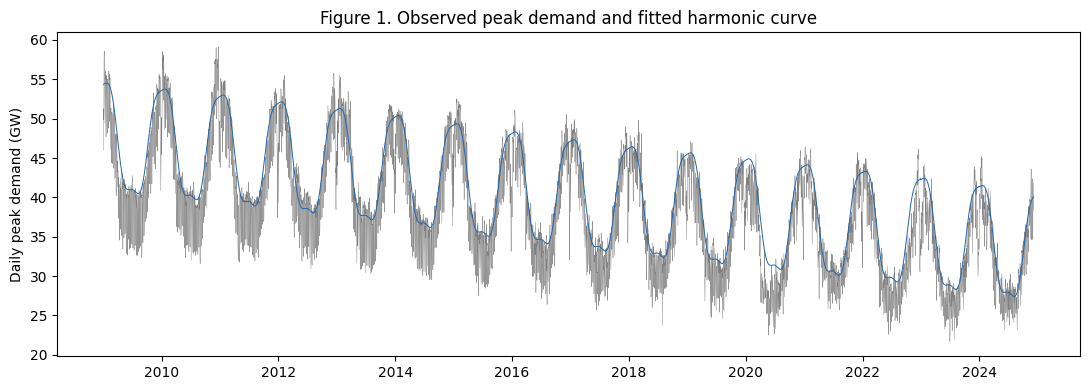

In [10]:
# Figure 1 — observed peak demand vs the fitted harmonic curve (weekday=Mon, holiday=False)
ref = day.copy(); ref["wday"] = pd.Categorical(["Mon"] * len(ref), categories=WDAYS); ref["is_holiday"] = False
day["fit_ref"] = desc.predict(ref)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(day["date"], day["peak_gw"], color="grey", lw=0.3)
ax.plot(day["date"], day["fit_ref"], color="#2166ac", lw=0.7)
ax.set_ylabel("Daily peak demand (GW)"); ax.set_title("Figure 1. Observed peak demand and fitted harmonic curve")
plt.tight_layout(); plt.show()

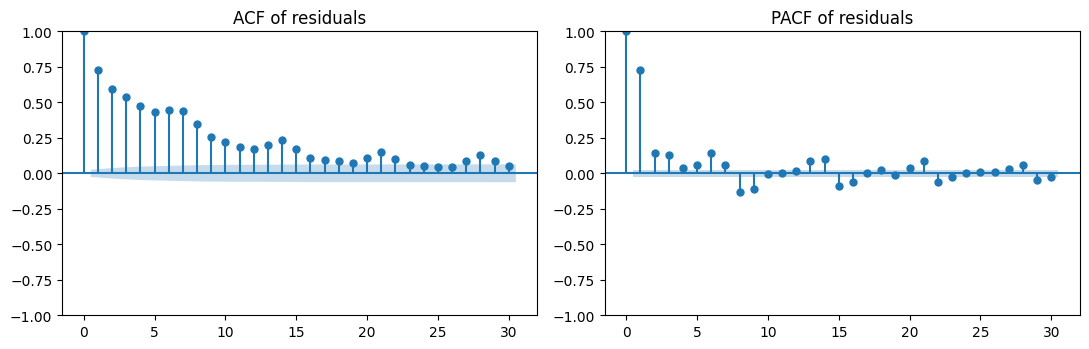

In [11]:
# Figure 2 — residual ACF and PACF
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
plot_acf(res, lags=30, ax=ax[0]); ax[0].set_title("ACF of residuals")
plot_pacf(res, lags=30, ax=ax[1], method="ywm"); ax[1].set_title("PACF of residuals")
plt.tight_layout(); plt.show()

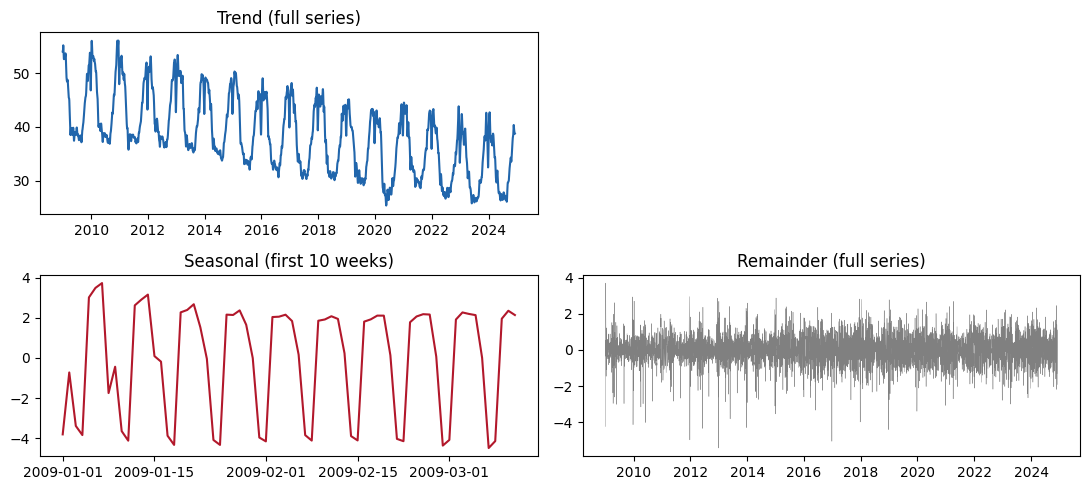

In [12]:
# Figure 3 — STL decomposition (weekly period); seasonal panel zoomed to the first 10 weeks
stl = STL(day["peak_gw"].values, period=7, seasonal=7, robust=False).fit()
fig, ax = plt.subplots(2, 2, figsize=(11, 5))
ax[0, 0].plot(day["date"], stl.trend, color="#2166ac"); ax[0, 0].set_title("Trend (full series)")
ax[0, 1].axis("off")
ax[1, 0].plot(day["date"][:70], stl.seasonal[:70], color="#b2182b"); ax[1, 0].set_title("Seasonal (first 10 weeks)")
ax[1, 1].plot(day["date"], stl.resid, color="grey", lw=0.3); ax[1, 1].set_title("Remainder (full series)")
plt.tight_layout(); plt.show()

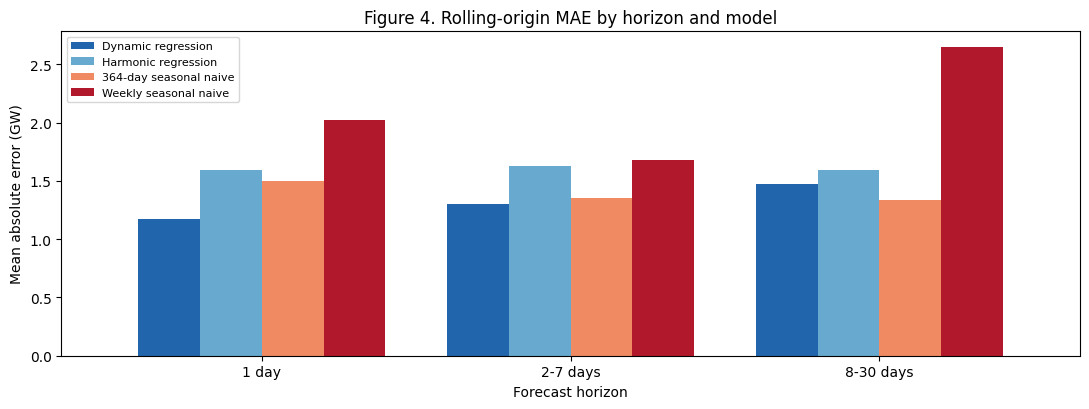

In [13]:
# Figure 4 — rolling-origin MAE by horizon and model
order_h = ["1 day", "2-7 days", "8-30 days"]
order_m = ["Dynamic regression", "Harmonic regression", "364-day seasonal naive", "Weekly seasonal naive"]
colors  = {"Dynamic regression": "#2166ac", "Harmonic regression": "#67a9cf",
           "364-day seasonal naive": "#ef8a62", "Weekly seasonal naive": "#b2182b"}
piv = roll_acc.pivot(index="Horizon", columns="Model", values="MAE").reindex(order_h)[order_m]
ax = piv.plot(kind="bar", figsize=(11, 4.2), color=[colors[m] for m in order_m], width=0.8)
ax.set_ylabel("Mean absolute error (GW)"); ax.set_xlabel("Forecast horizon")
ax.set_title("Figure 4. Rolling-origin MAE by horizon and model"); plt.xticks(rotation=0)
ax.legend(loc="upper left", fontsize=8); plt.tight_layout(); plt.show()

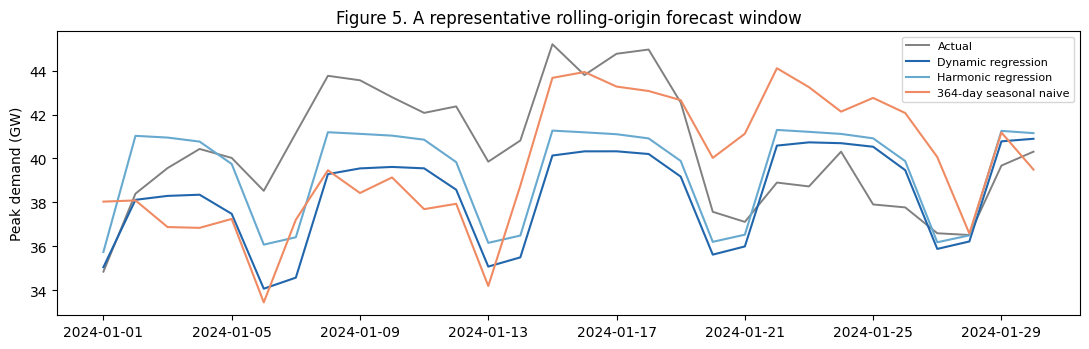

In [14]:
# Figure 5 — a representative 30-day rolling-origin forecast window (first origin)
w = roll[roll["origin"] == roll["origin"].min()]
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(w["date"], w["actual"], color="grey", lw=1.4, label="Actual")
ax.plot(w["date"], w["Dynamic regression"], color="#2166ac", label="Dynamic regression")
ax.plot(w["date"], w["Harmonic regression"], color="#67a9cf", label="Harmonic regression")
ax.plot(w["date"], w["364-day seasonal naive"], color="#ef8a62", label="364-day seasonal naive")
ax.set_ylabel("Peak demand (GW)"); ax.set_title("Figure 5. A representative rolling-origin forecast window")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()